# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [1]:
# ============================================================
# 1. CONFIGURAÇÃO DO AMBIENTE
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Semente fixa para garantir reprodutibilidade
RANDOM_STATE = 42

# Repositório do projeto
REPO_URL = "https://github.com/andrerochadeoliveira/postech-tech-challenge-fase2-template.git"
PROJECT_PATH = Path("/content/postech-tech-challenge-fase2-template")

# Clona o repositório caso ele ainda não esteja disponível
if not PROJECT_PATH.exists():
    !git clone {REPO_URL}
else:
    print("Repositório já disponível nesta sessão.")

# Caminho da base construída no notebook 00
DATA_PATH = PROJECT_PATH / "data" / "processed" / "dataset_base.csv"

# Variável-alvo
TARGET = "target"

pd.set_option("display.max_columns", None)

print("\nDiretório do projeto:")
print(PROJECT_PATH)

print("\nArquivo esperado:")
print(DATA_PATH)

Cloning into 'postech-tech-challenge-fase2-template'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 189 (delta 83), reused 16 (delta 16), pack-reused 77 (from 1)
Receiving objects: 100% (189/189), 2.46 MiB | 9.79 MiB/s, done.
Resolving deltas: 100% (105/105), done.

Diretório do projeto:
/content/postech-tech-challenge-fase2-template

Arquivo esperado:
/content/postech-tech-challenge-fase2-template/data/processed/dataset_base.csv


In [2]:
# ============================================================
# ATUALIZAÇÃO DO REPOSITÓRIO COM AS SUAS ALTERAÇÕES DO GITHUB
# ============================================================

# Entra no diretório do projeto e puxa as atualizações do GitHub
!cd {PROJECT_PATH} && git pull

Already up to date.


In [3]:
# Gera a base analítica necessária para o EDA
!jupyter nbconvert \
    --to notebook \
    --execute \
    "$PROJECT_PATH/notebooks/00_preparacao_dados.ipynb" \
    --output "/tmp/00_preparacao_dados_executado.ipynb"

[NbConvertApp] Converting notebook /content/postech-tech-challenge-fase2-template/notebooks/00_preparacao_dados.ipynb to notebook
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] Writing 69358 bytes to /tmp/00_preparacao_dados_executado.ipynb


In [4]:
# ============================================================
# VERIFICAÇÃO DA BASE GERADA
# ============================================================

print("Arquivo existe:", DATA_PATH.exists())

if DATA_PATH.exists():
    tamanho_mb = DATA_PATH.stat().st_size / (1024 ** 2)
    print(f"Tamanho do arquivo: {tamanho_mb:.2f} MB")
    print("Caminho:", DATA_PATH)

Arquivo existe: True
Tamanho do arquivo: 1.99 MB
Caminho: /content/postech-tech-challenge-fase2-template/data/processed/dataset_base.csv


In [5]:
# ============================================================
# 2. CARREGAMENTO DA BASE ANALÍTICA
# ============================================================

# Verifica se a base produzida pelo notebook 00 está disponível
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "O arquivo dataset_base.csv não foi encontrado. "
        "Execute primeiro o notebook 00_preparacao_dados.ipynb "
        "para gerar a base analítica."
    )

df = pd.read_csv(DATA_PATH)

print("Base carregada com sucesso.")
print("Dimensão:", df.shape)

df.head()

Base carregada com sucesso.
Dimensão: (16541, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [6]:
# ============================================================
# 3. VISÃO GERAL DA BASE
# ============================================================

print("Número de registros:", df.shape[0])
print("Número de variáveis:", df.shape[1])
print("Número de clientes:", df["ID"].nunique())

print("\nTipos das variáveis:")
print(df.dtypes.value_counts())

print("\nValores ausentes:")
print(df.isna().sum().sort_values(ascending=False).head())

percentual_ausente = (
    df["OCCUPATION_TYPE"].isna().mean() * 100
)

print(
    f"\nPercentual ausente em OCCUPATION_TYPE: "
    f"{percentual_ausente:.2f}%"
)

Número de registros: 16541
Número de variáveis: 19
Número de clientes: 16541

Tipos das variáveis:
int64      9
object     8
float64    2
Name: count, dtype: int64

Valores ausentes:
OCCUPATION_TYPE    5090
CODE_GENDER           0
ID                    0
FLAG_OWN_CAR          0
FLAG_OWN_REALTY       0
dtype: int64

Percentual ausente em OCCUPATION_TYPE: 30.77%



### Interpretação

A base analítica contém **16.541 registros e 16.541 clientes distintos**, com 19 variáveis, sendo 11 armazenadas como numéricas e 8 como categóricas.

A única variável com valores ausentes é `OCCUPATION_TYPE`, com **5.090 registros sem informação (30,77%)**.

Considerando a proporção de dados ausentes, o tratamento dessa variável será realizado posteriormente no pré-processamento, sem exclusão automática dos clientes nesta etapa.


In [7]:
# ============================================================
# 4. IDENTIFICAÇÃO DOS TIPOS DE VARIÁVEIS
# ============================================================

variaveis_numericas = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

variaveis_categoricas = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Variáveis armazenadas como numéricas:")
print(variaveis_numericas)

print("\nVariáveis armazenadas como categóricas:")
print(variaveis_categoricas)

Variáveis armazenadas como numéricas:
['ID', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'target']

Variáveis armazenadas como categóricas:
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


In [8]:
# ============================================================
# 5. QUANTIDADE DE VALORES ÚNICOS POR VARIÁVEL
# ============================================================

valores_unicos = (
    df.nunique()
    .sort_values()
)

print(valores_unicos)

FLAG_MOBIL                 1
CODE_GENDER                2
FLAG_OWN_REALTY            2
FLAG_OWN_CAR               2
FLAG_PHONE                 2
FLAG_WORK_PHONE            2
FLAG_EMAIL                 2
target                     2
NAME_FAMILY_STATUS         5
NAME_INCOME_TYPE           5
NAME_EDUCATION_TYPE        5
NAME_HOUSING_TYPE          6
CNT_CHILDREN               7
CNT_FAM_MEMBERS            8
OCCUPATION_TYPE           18
AMT_INCOME_TOTAL         228
DAYS_EMPLOYED           3055
DAYS_BIRTH              5508
ID                     16541
dtype: int64


### Classificação das variáveis

A análise da cardinalidade mostra que o tipo de armazenamento das variáveis não corresponde necessariamente à sua natureza estatística.

A variável `ID` funciona exclusivamente como identificador do cliente e não deve ser utilizada como variável explicativa na modelagem. O `target` e as variáveis `FLAG_MOBIL`, `FLAG_WORK_PHONE`, `FLAG_PHONE` e `FLAG_EMAIL` são binárias, embora estejam armazenadas como números inteiros.

Entre as variáveis binárias, `FLAG_MOBIL` apresenta apenas um valor em toda a base, não possuindo variabilidade entre os clientes. Por esse motivo, não apresenta poder discriminatório e deverá ser descartada no pré-processamento.

As demais variáveis numéricas representam características quantitativas ou discretas dos clientes, enquanto as variáveis armazenadas como `object` representam características categóricas. A variável `OCCUPATION_TYPE`, por exemplo, apresenta múltiplas categorias e valores ausentes, que serão tratados posteriormente.

Essa classificação será considerada nas etapas seguintes para definir as estratégias de análise, tratamento e preparação das variáveis para a modelagem.

In [9]:
# ============================================================
# 6. AGRUPAMENTO DAS VARIÁVEIS PARA O EDA
# ============================================================

IDENTIFICADOR = "ID"

variaveis_quantitativas = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS"
]

variaveis_binarias = [
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "FLAG_MOBIL",
    "FLAG_WORK_PHONE",
    "FLAG_PHONE",
    "FLAG_EMAIL"
]

variaveis_categoricas = [
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

print("Quantitativas:", len(variaveis_quantitativas))
print("Binárias:", len(variaveis_binarias))
print("Categóricas:", len(variaveis_categoricas))
print("Target:", TARGET)
print("Identificador:", IDENTIFICADOR)

Quantitativas: 5
Binárias: 7
Categóricas: 5
Target: target
Identificador: ID


In [10]:
# ============================================================
# INVESTIGAÇÃO DE POSSÍVEIS DUPLICIDADES DE PERFIL
# ============================================================

# O ID é excluído porque queremos identificar registros
# com perfis cadastrais idênticos, mas IDs diferentes.
#
# O target também é excluído, pois faz parte da análise
# posterior e não deve ser utilizado para definir o perfil.
#
# AGE_YEARS, quando existir, também não deve ser considerada,
# pois é uma transformação de DAYS_BIRTH.

colunas_perfil = [
    coluna
    for coluna in df.columns
    if coluna not in ["ID", "target", "AGE_YEARS"]
]

# Agrupa clientes pelo conjunto completo de características
# cadastrais, incluindo os valores ausentes.
grupos_perfil = (
    df
    .groupby(
        colunas_perfil,
        dropna=False,
        sort=False
    )["ID"]
    .agg(list)
    .reset_index(name="IDs")
)

# Quantidade de IDs diferentes em cada perfil
grupos_perfil["qtd_ids"] = (
    grupos_perfil["IDs"].apply(len)
)

# Mantém somente perfis compartilhados por mais de um ID
grupos_gemeos = grupos_perfil[
    grupos_perfil["qtd_ids"] > 1
].copy()

print("=" * 60)
print("POSSÍVEIS DUPLICIDADES DE PERFIL")
print("=" * 60)

print(
    f"Perfis compartilhados por múltiplos IDs: "
    f"{len(grupos_gemeos):,}"
)

print(
    f"Clientes pertencentes a esses perfis: "
    f"{grupos_gemeos['qtd_ids'].sum():,}"
)

POSSÍVEIS DUPLICIDADES DE PERFIL
Perfis compartilhados por múltiplos IDs: 3,805
Clientes pertencentes a esses perfis: 13,423


In [11]:
# ============================================================
# VERIFICAÇÃO DE TARGET ENTRE POSSÍVEIS DUPLICIDADES
# ============================================================

# Dicionário ID -> target
target_por_id = (
    df
    .set_index("ID")[TARGET]
    .to_dict()
)

# Identifica quais targets aparecem dentro de cada perfil
grupos_gemeos["targets"] = grupos_gemeos["IDs"].apply(
    lambda ids: sorted(
        {target_por_id[id_cliente] for id_cliente in ids}
    )
)

# Quantidade de classes de target presentes no grupo
grupos_gemeos["qtd_targets"] = (
    grupos_gemeos["targets"].apply(len)
)

# Perfis em que IDs diferentes apresentam targets diferentes
grupos_target_diferente = grupos_gemeos[
    grupos_gemeos["qtd_targets"] > 1
].copy()

print("=" * 60)
print("IMPACTO SOBRE A TARGET")
print("=" * 60)

print(
    f"Perfis com target igual entre os IDs: "
    f"{(grupos_gemeos['qtd_targets'] == 1).sum():,}"
)

print(
    f"Perfis com targets diferentes: "
    f"{len(grupos_target_diferente):,}"
)

print(
    f"IDs pertencentes a perfis com targets diferentes: "
    f"{grupos_target_diferente['qtd_ids'].sum():,}"
)

IMPACTO SOBRE A TARGET
Perfis com target igual entre os IDs: 3,531
Perfis com targets diferentes: 274
IDs pertencentes a perfis com targets diferentes: 1,112


In [12]:
# ============================================================
# EXEMPLOS DE PERFIS COM TARGET DIFERENTE
# ============================================================

# IDs pertencentes aos primeiros perfis com target diferente
ids_exemplo = (
    grupos_target_diferente
    .iloc[0]["IDs"]
)

df_exemplo_gemeos = (
    df[
        df["ID"].isin(ids_exemplo)
    ]
    .sort_values("ID")
)

df_exemplo_gemeos

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
8,5008830,F,N,Y,0,157500.0,Working,Secondary / secondary special,Married,House / apartment,-10031,-1469,1,0,1,0,Laborers,2.0,0
9,5008831,F,N,Y,0,157500.0,Working,Secondary / secondary special,Married,House / apartment,-10031,-1469,1,0,1,0,Laborers,2.0,1
10,5008832,F,N,Y,0,157500.0,Working,Secondary / secondary special,Married,House / apartment,-10031,-1469,1,0,1,0,Laborers,2.0,0



### Interpretação

A análise identificou **3.805 perfis cadastrais compartilhados por mais de um ID**, envolvendo **13.423 clientes**.

Entre esses perfis, **274 apresentam classificações diferentes de `target`**, abrangendo **1.112 clientes**.

A coincidência das características cadastrais não comprova que os registros pertençam à mesma pessoa. Por esse motivo, são considerados possíveis registros de mesmo perfil, e não duplicidades confirmadas.

Esses resultados serão considerados no pré-processamento e na divisão das amostras, para reduzir o risco de compartilhamento de perfis idênticos entre treinamento e teste.


In [13]:
# ============================================================
# RESUMO DAS POSSÍVEIS DUPLICIDADES DE PERFIL
# ============================================================

resumo_gemeos = pd.DataFrame({
    "Indicador": [
        "Perfis compartilhados por múltiplos IDs",
        "Clientes nesses perfis",
        "Perfis com targets diferentes",
        "IDs em perfis com targets diferentes"
    ],
    "Quantidade": [
        len(grupos_gemeos),
        grupos_gemeos["qtd_ids"].sum(),
        len(grupos_target_diferente),
        grupos_target_diferente["qtd_ids"].sum()
    ]
})

resumo_gemeos

,Indicador,Quantidade
0,Perfis compartilhados por múltiplos IDs,3805
1,Clientes nesses perfis,13423
2,Perfis com targets diferentes,274
3,IDs em perfis com targets diferentes,1112


## 2 — Análise das variáveis quantitativas

Nesta etapa são analisadas as distribuições e estatísticas descritivas das variáveis quantitativas. O objetivo é identificar características relevantes, possíveis assimetrias, valores extremos e situações que necessitem de investigação antes do pré-processamento.

In [14]:
# ============================================================
# 7. ESTATÍSTICAS DESCRITIVAS DAS VARIÁVEIS QUANTITATIVAS
# ============================================================

estatisticas_quantitativas = (
    df[variaveis_quantitativas]
    .describe()
    .T
)

estatisticas_quantitativas

,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,16541.0,0.418657,0.734526,0.0,0.0,0.0,1.0,14.0
AMT_INCOME_TOTAL,16541.0,189344.838039,101356.024444,27000.0,121500.0,166500.0,225000.0,1575000.0
DAYS_BIRTH,16541.0,-16129.423735,4096.074783,-25152.0,-19478.0,-15771.0,-12736.0,-7757.0
DAYS_EMPLOYED,16541.0,57131.883804,135894.960406,-15713.0,-3291.0,-1679.0,-436.0,365243.0
CNT_FAM_MEMBERS,16541.0,2.193942,0.901692,1.0,2.0,2.0,3.0,15.0


### Interpretação

As variáveis quantitativas apresentam diferentes escalas e distribuições. A renda possui assimetria à direita, enquanto `DAYS_EMPLOYED` apresenta valores especiais que afetam suas estatísticas descritivas.

In [15]:
# ============================================================
# 8. INVESTIGAÇÃO DE DAYS_EMPLOYED
# ============================================================

print("Maiores valores de DAYS_EMPLOYED:")
print(
    df["DAYS_EMPLOYED"]
    .value_counts()
    .sort_index(ascending=False)
    .head(10)
)

print("\nQuantidade de valores positivos:")
print((df["DAYS_EMPLOYED"] > 0).sum())

print("\nPercentual de valores positivos:")
print(
    round(
        (df["DAYS_EMPLOYED"] > 0).mean() * 100,
        2
    )
)

Maiores valores de DAYS_EMPLOYED:
DAYS_EMPLOYED
 365243    2693
-43           1
-65           1
-66           1
-71           1
-73           9
-89           4
-91           3
-92           3
-93           8
Name: count, dtype: int64

Quantidade de valores positivos:
2693

Percentual de valores positivos:
16.28


### Interpretação

Foram identificados **2.693 registros (16,28%)** com o código `365243`, que não representa tempo de emprego plausível e deverá ser tratado no pré-processamento.

In [16]:
# ============================================================
# 9. INVESTIGAÇÃO DA COMPOSIÇÃO FAMILIAR
# ============================================================

print("Distribuição de CNT_CHILDREN:")
print(
    df["CNT_CHILDREN"]
    .value_counts()
    .sort_index()
)

print("\nDistribuição de CNT_FAM_MEMBERS:")
print(
    df["CNT_FAM_MEMBERS"]
    .value_counts()
    .sort_index()
)

Distribuição de CNT_CHILDREN:
CNT_CHILDREN
0     11606
1      3233
2      1471
3       198
4        27
5         4
14        2
Name: count, dtype: int64

Distribuição de CNT_FAM_MEMBERS:
CNT_FAM_MEMBERS
1.0     3114
2.0     9000
3.0     2809
4.0     1393
5.0      194
6.0       26
7.0        3
15.0       2
Name: count, dtype: int64


### Interpretação

Predominam clientes sem filhos e famílias pequenas. Dos 16.541 clientes, **11.606 não possuem filhos**, e **9.000 pertencem a famílias com dois membros**.

In [17]:
# ============================================================
# 10. VERIFICAÇÃO DOS CASOS EXTREMOS DE COMPOSIÇÃO FAMILIAR
# ============================================================

casos_extremos_familia = df.loc[
    (df["CNT_CHILDREN"] >= 7) |
    (df["CNT_FAM_MEMBERS"] >= 9),
    [
        "ID",
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS",
        "NAME_FAMILY_STATUS"
    ]
].sort_values(
    ["CNT_CHILDREN", "CNT_FAM_MEMBERS"],
    ascending=False
)

casos_extremos_familia

,ID,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS
6357,5061207,14,15.0,Separated
6358,5061211,14,15.0,Separated


### Interpretação

Foram identificados **dois registros com 14 filhos e 15 membros familiares**. Os valores são coerentes entre si e serão mantidos nesta etapa, sem evidência suficiente de erro.

In [18]:
# ============================================================
# 11. INVESTIGAÇÃO DA RENDA
# ============================================================

print("Quantis de AMT_INCOME_TOTAL:")

print(
    df["AMT_INCOME_TOTAL"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99, 1.00])
)

print("\n10 maiores valores de renda:")

print(
    df["AMT_INCOME_TOTAL"]
    .nlargest(10)
)

Quantis de AMT_INCOME_TOTAL:
0.50     166500.0
0.75     225000.0
0.90     315000.0
0.95     360000.0
0.99     562500.0
1.00    1575000.0
Name: AMT_INCOME_TOTAL, dtype: float64

10 maiores valores de renda:
15326    1575000.0
322      1350000.0
2231     1125000.0
9598     1125000.0
12037    1125000.0
12534     945000.0
187       900000.0
1567      900000.0
1568      900000.0
1569      900000.0
Name: AMT_INCOME_TOTAL, dtype: float64


### Interpretação

A renda apresenta mediana de **166.500** e valor máximo de **1.575.000**, evidenciando assimetria à direita e valores elevados que merecem atenção no pré-processamento.

In [19]:
# ============================================================
# 12. CONVERSÃO DE DAYS_BIRTH PARA IDADE
# ============================================================

# Cria uma variável apenas para facilitar a interpretação no EDA.
# A variável original é preservada.
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365.25)

print(df["AGE_YEARS"].describe().round(2))

count    16541.00
mean        44.16
std         11.21
min         21.24
25%         34.87
50%         43.18
75%         53.33
max         68.86
Name: AGE_YEARS, dtype: float64


### Interpretação

A idade aproximada varia de **21 a 69 anos**, com média de **44,16 anos**. A conversão facilita a análise sem substituir a variável original.

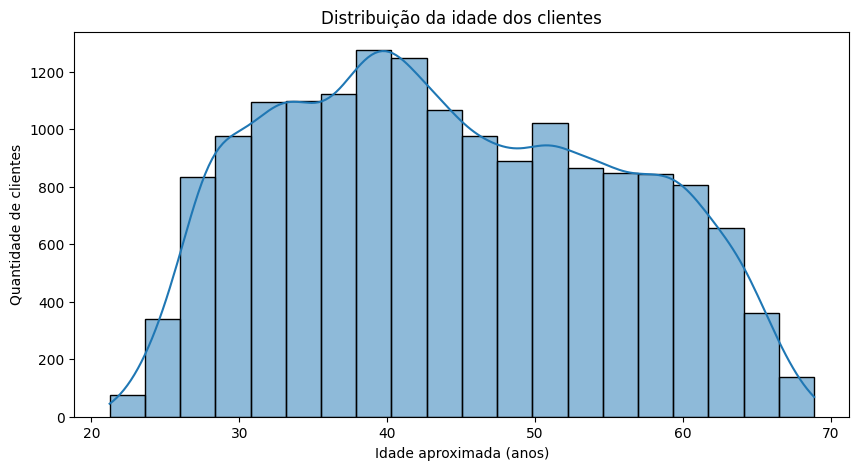

In [20]:
# ============================================================
# 13. DISTRIBUIÇÃO DA IDADE
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="AGE_YEARS",
    bins=20,
    kde=True
)

plt.title("Distribuição da idade dos clientes")
plt.xlabel("Idade aproximada (anos)")
plt.ylabel("Quantidade de clientes")

plt.show()

### Interpretação

O histograma mostra concentração nas idades intermediárias, com mediana de **43,18 anos** e sem valores etários aparentemente incompatíveis.

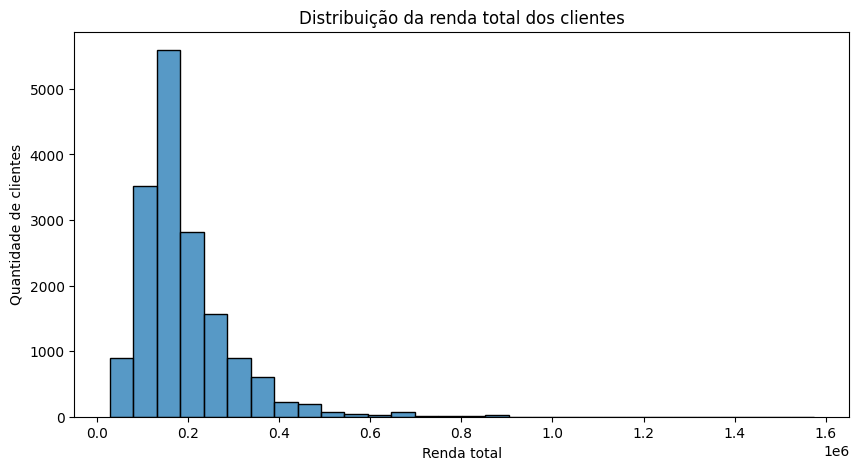

In [21]:
# ============================================================
# 14. DISTRIBUIÇÃO DA RENDA TOTAL
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    bins=30
)

plt.title("Distribuição da renda total dos clientes")
plt.xlabel("Renda total")
plt.ylabel("Quantidade de clientes")

plt.show()

### Interpretação

O histograma evidencia concentração nas rendas inferiores e uma cauda longa à direita, influenciada por clientes com rendimentos elevados.

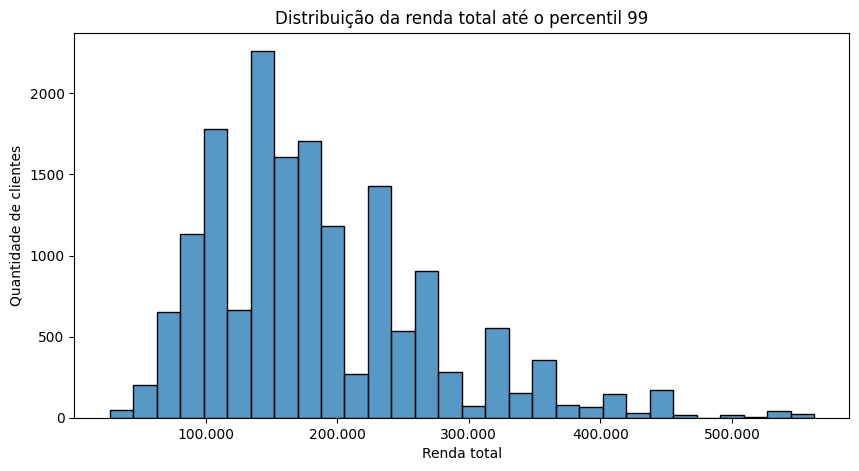

Percentil 99 da renda: 562,500.00


In [22]:
# ============================================================
# 15. DISTRIBUIÇÃO DA RENDA ATÉ O PERCENTIL 99
# ============================================================

limite_renda_99 = df["AMT_INCOME_TOTAL"].quantile(0.99)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[df["AMT_INCOME_TOTAL"] <= limite_renda_99],
    x="AMT_INCOME_TOTAL",
    bins=30
)

plt.title("Distribuição da renda total até o percentil 99")
plt.xlabel("Renda total")
plt.ylabel("Quantidade de clientes")

from matplotlib.ticker import FuncFormatter

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
)

plt.show()

print(f"Percentil 99 da renda: {limite_renda_99:,.2f}")

### Interpretação

A limitação visual ao percentil 99 (**562.500**) permite observar melhor a distribuição central da renda, sem remover registros da base.

In [23]:
# ============================================================
# 16. TEMPO DE EMPREGO EM ANOS
# ============================================================

# Considera somente os valores negativos de DAYS_EMPLOYED.
# O código especial 365243 não entra neste cálculo.
tempo_emprego_valido = df.loc[
    df["DAYS_EMPLOYED"] < 0,
    "DAYS_EMPLOYED"
]

tempo_emprego_anos = -tempo_emprego_valido / 365.25

print("Registros com tempo de emprego válido:", len(tempo_emprego_anos))
print("\nEstatísticas do tempo de emprego (anos):")
print(tempo_emprego_anos.describe().round(2))

Registros com tempo de emprego válido: 13848

Estatísticas do tempo de emprego (anos):
count    13848.00
mean         7.63
std          6.66
min          0.12
25%          2.85
50%          5.92
75%         10.04
max         43.02
Name: DAYS_EMPLOYED, dtype: float64


### Interpretação

Considerando **13.848 registros válidos**, o tempo de emprego apresenta média de **7,63 anos** e mediana de **5,92 anos**.

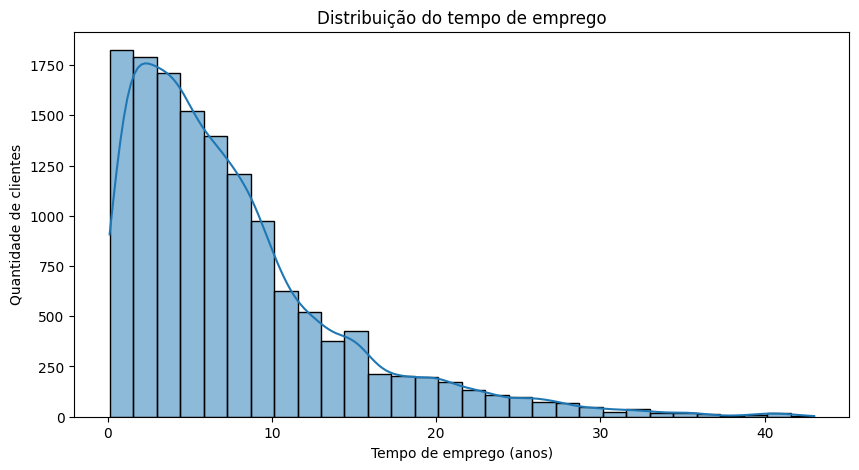

In [24]:
# ============================================================
# 17. DISTRIBUIÇÃO DO TEMPO DE EMPREGO
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    x=tempo_emprego_anos,
    bins=30,
    kde=True
)

plt.title("Distribuição do tempo de emprego")
plt.xlabel("Tempo de emprego (anos)")
plt.ylabel("Quantidade de clientes")

plt.show()

### Interpretação

A distribuição concentra-se nos menores tempos de emprego e apresenta cauda à direita, com alguns registros de longa permanência profissional.

In [25]:
# ============================================================
# 18. RELAÇÃO ENTRE FILHOS E TAMANHO DA FAMÍLIA
# ============================================================

correlacao_familia = df[
    ["CNT_CHILDREN", "CNT_FAM_MEMBERS"]
].corr()

print(correlacao_familia)

                 CNT_CHILDREN  CNT_FAM_MEMBERS
CNT_CHILDREN         1.000000         0.888471
CNT_FAM_MEMBERS      0.888471         1.000000


### Interpretação

A correlação de Pearson entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` é de **0,888**, indicando forte associação positiva e possível redundância.


### Interpretação consolidada — Variáveis quantitativas

As análises descritivas e os gráficos mostram que a população possui idade média de **44,16 anos** e mediana de **43,18 anos**, com valores entre aproximadamente 21 e 69 anos.

A renda (`AMT_INCOME_TOTAL`) apresenta assimetria à direita, com média de aproximadamente **189,3 mil**, mediana de **166,5 mil** e valor máximo de **1,575 milhão**. A visualização limitada ao percentil 99 permite observar melhor a concentração dos valores, sem excluir registros da base.

Em `DAYS_EMPLOYED`, foram identificados **2.693 registros (16,28%)** com o código especial `365243`. Considerando apenas os **13.848 registros com valores interpretáveis**, o tempo de emprego apresenta mediana de **5,92 anos**.

A composição familiar concentra-se em clientes com poucos filhos e famílias pequenas. Foram identificados dois registros extremos com 14 filhos e 15 membros familiares, sem evidências suficientes para classificá-los como erros.

A correlação entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` é de aproximadamente **0,89**, indicando forte associação e possível redundância entre essas informações.

Essas características deverão ser consideradas no pré-processamento, especialmente no tratamento de valores especiais, na análise de valores extremos e na seleção das variáveis explicativas.


## 3 — Análise das variáveis categóricas e binárias

Nesta etapa são analisadas as distribuições das características categóricas e binárias dos clientes. O objetivo é identificar categorias predominantes, categorias pouco frequentes, variáveis sem variabilidade e possíveis aspectos relevantes para o pré-processamento e a modelagem.

In [26]:
# ============================================================
# 19. DISTRIBUIÇÃO DAS VARIÁVEIS BINÁRIAS
# ============================================================

for coluna in variaveis_binarias:
    print(f"\n{coluna}")
    print("-" * len(coluna))

    resumo = pd.DataFrame({
        "quantidade": df[coluna].value_counts(dropna=False),
        "percentual": (
            df[coluna]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })

    print(resumo)


CODE_GENDER
-----------
             quantidade  percentual
CODE_GENDER                        
F                 10909       65.95
M                  5632       34.05

FLAG_OWN_CAR
------------
              quantidade  percentual
FLAG_OWN_CAR                        
N                  10032       60.65
Y                   6509       39.35

FLAG_OWN_REALTY
---------------
                 quantidade  percentual
FLAG_OWN_REALTY                        
Y                     10740       64.93
N                      5801       35.07

FLAG_MOBIL
----------
            quantidade  percentual
FLAG_MOBIL                        
1                16541       100.0

FLAG_WORK_PHONE
---------------
                 quantidade  percentual
FLAG_WORK_PHONE                        
0                     12661       76.54
1                      3880       23.46

FLAG_PHONE
----------
            quantidade  percentual
FLAG_PHONE                        
0                11570       69.95
1             

### Interpretação

Predominam clientes do sexo feminino (**65,95%**), sem automóvel (**60,65%**) e com imóvel próprio (**64,93%**). `FLAG_MOBIL` é constante e não contribui para diferenciar clientes.

In [27]:
# ============================================================
# 20. DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS
# ============================================================

for coluna in variaveis_categoricas:
    print(f"\n{coluna}")
    print("-" * len(coluna))

    resumo = pd.DataFrame({
        "quantidade": df[coluna].value_counts(dropna=False),
        "percentual": (
            df[coluna]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })

    print(resumo)


NAME_INCOME_TYPE
----------------
                      quantidade  percentual
NAME_INCOME_TYPE                            
Working                     8467       51.19
Commercial associate        3992       24.13
Pensioner                   2709       16.38
State servant               1364        8.25
Student                        9        0.05

NAME_EDUCATION_TYPE
-------------------
                               quantidade  percentual
NAME_EDUCATION_TYPE                                  
Secondary / secondary special       11123       67.25
Higher education                     4581       27.69
Incomplete higher                     644        3.89
Lower secondary                       176        1.06
Academic degree                        17        0.10

NAME_FAMILY_STATUS
------------------
                      quantidade  percentual
NAME_FAMILY_STATUS                          
Married                    11575       69.98
Single / not married        2101       12.70
Civil marria

### Interpretação

As categorias apresentam frequências distintas, com concentração em alguns grupos e baixa representatividade em outros. Essas diferenças deverão orientar a codificação das variáveis.

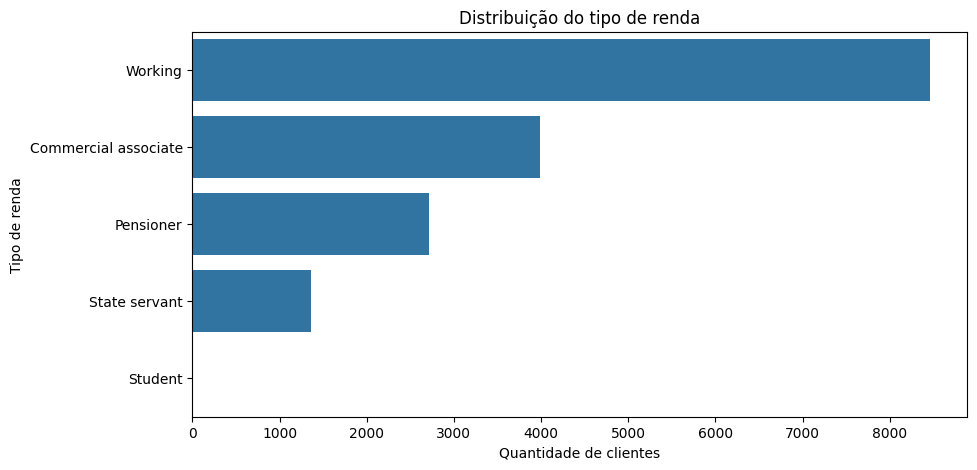

In [28]:
# ============================================================
# 21. DISTRIBUIÇÃO DO TIPO DE RENDA
# ============================================================

plt.figure(figsize=(10, 5))

ordem = (
    df["NAME_INCOME_TYPE"]
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    y="NAME_INCOME_TYPE",
    order=ordem
)

plt.title("Distribuição do tipo de renda")
plt.xlabel("Quantidade de clientes")
plt.ylabel("Tipo de renda")

plt.show()

### Interpretação

Predominam `Working` (**51,19%**) e `Commercial associate` (**24,13%**), que representam conjuntamente mais de 75% dos clientes.

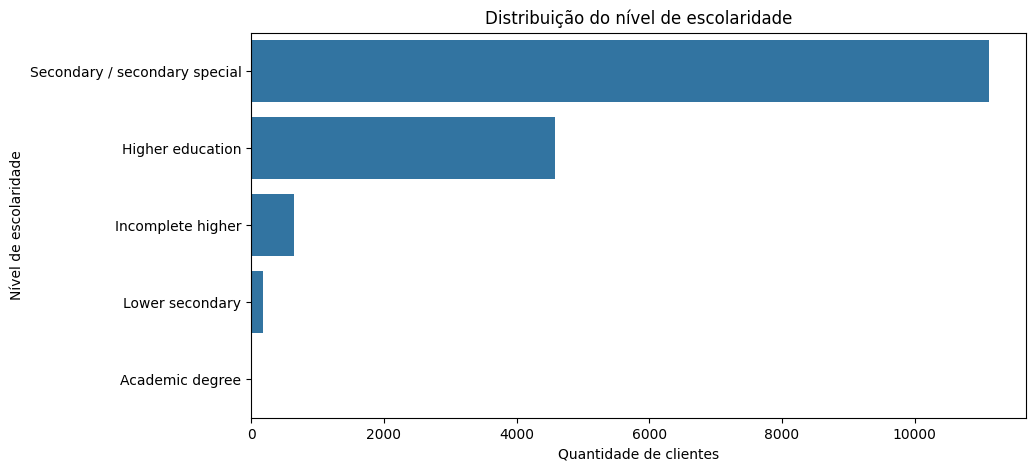

In [29]:
# ============================================================
# 22. DISTRIBUIÇÃO DO NÍVEL DE ESCOLARIDADE
# ============================================================

plt.figure(figsize=(10, 5))

ordem = (
    df["NAME_EDUCATION_TYPE"]
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    y="NAME_EDUCATION_TYPE",
    order=ordem
)

plt.title("Distribuição do nível de escolaridade")
plt.xlabel("Quantidade de clientes")
plt.ylabel("Nível de escolaridade")

plt.show()

### Interpretação

A escolaridade concentra-se em `Secondary / secondary special` (**67,25%**) e `Higher education` (**27,69%**). As demais categorias possuem menor representatividade.

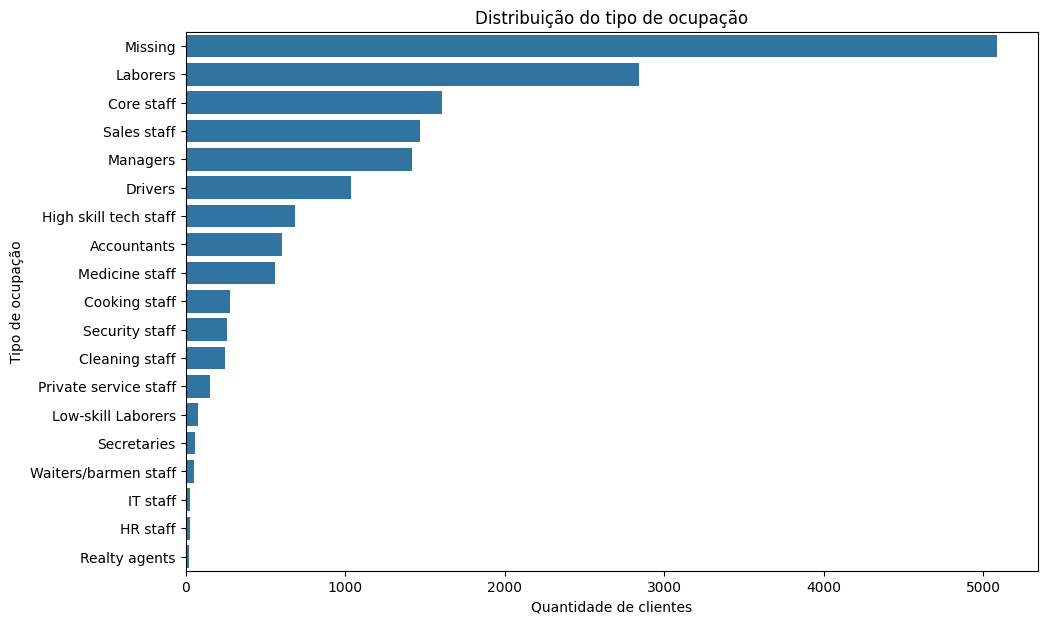

In [30]:
# ============================================================
# 23. DISTRIBUIÇÃO DO TIPO DE OCUPAÇÃO
# ============================================================

ocupacao_plot = df["OCCUPATION_TYPE"].fillna("Missing")

ordem_ocupacao = (
    ocupacao_plot
    .value_counts()
    .index
)

plt.figure(figsize=(11, 7))

sns.countplot(
    y=ocupacao_plot,
    order=ordem_ocupacao
)

plt.title("Distribuição do tipo de ocupação")
plt.xlabel("Quantidade de clientes")
plt.ylabel("Tipo de ocupação")

plt.show()

### Interpretação

`OCCUPATION_TYPE` possui **5.090 valores ausentes (30,77%)**. A elevada ausência de informação e a existência de categorias pouco frequentes exigem atenção no pré-processamento.


### Interpretação consolidada — Variáveis categóricas e binárias

As distribuições mostram predominância de clientes do sexo feminino (**65,95%**), sem automóvel próprio (**60,65%**) e com imóvel próprio (**64,93%**).

Entre as informações de contato, **23,46%** possuem telefone de trabalho registrado, **30,05%** possuem telefone e **9,33%** possuem e-mail. A variável `FLAG_MOBIL` apresenta valor constante em todos os registros e deverá ser descartada no pré-processamento.

Quanto ao tipo de renda, predominam as categorias `Working` (**51,19%**) e `Commercial associate` (**24,13%**).

Na escolaridade, destacam-se `Secondary / secondary special` (**67,25%**) e `Higher education` (**27,69%**).

A variável `OCCUPATION_TYPE` apresenta **5.090 registros ausentes (30,77%)**, além de categorias com diferentes frequências. Essa característica exige atenção no tratamento de valores ausentes e na codificação das variáveis categóricas.

As distribuições observadas orientam a preparação dos dados, mas não permitem, isoladamente, estabelecer relações com o evento representado pelo `target`.


## 4 — Análise da variável-alvo

A variável `target` representa o evento definido na etapa de preparação dos dados. Nesta etapa será analisada sua distribuição, com atenção à proporção entre as classes e ao possível desbalanceamento da base.

In [31]:
# ============================================================
# 24. DISTRIBUIÇÃO DO TARGET
# ============================================================

contagem_target = df[TARGET].value_counts().sort_index()

percentual_target = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

resumo_target = pd.DataFrame({
    "quantidade": contagem_target,
    "percentual": percentual_target
})

resumo_target

,quantidade,percentual
target,,
0,16010,96.79
1,531,3.21


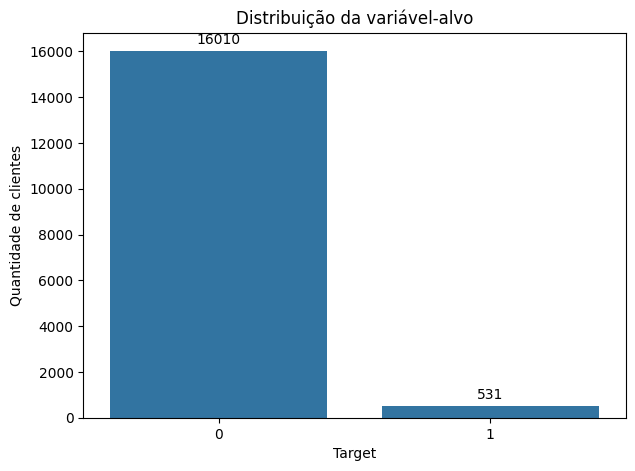

In [32]:
# ============================================================
# 25. VISUALIZAÇÃO DA DISTRIBUIÇÃO DO TARGET
# ============================================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=TARGET,
    order=[0, 1]
)

plt.title("Distribuição da variável-alvo")
plt.xlabel("Target")
plt.ylabel("Quantidade de clientes")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.show()


### Interpretação — Distribuição do TARGET

A variável-alvo apresenta forte desbalanceamento: **16.010 clientes (96,79%)** pertencem à classe 0 e **531 (3,21%)** à classe 1.

A classe 1 representa os clientes que atenderam aos critérios de evento de risco definidos na etapa de preparação dos dados.

Esse desbalanceamento deverá ser considerado na divisão das amostras, no treinamento e na avaliação dos modelos, priorizando métricas adequadas à identificação da classe minoritária.


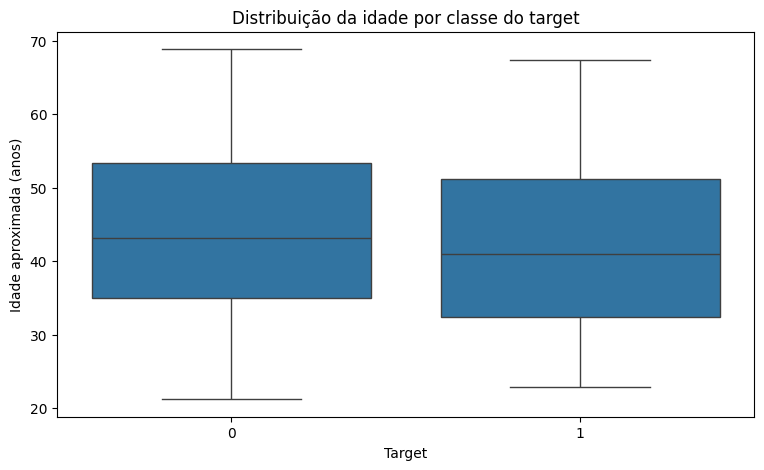

In [33]:
# ============================================================
# 26. IDADE POR CLASSE DO TARGET
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x=TARGET,
    y="AGE_YEARS"
)

plt.title("Distribuição da idade por classe do target")
plt.xlabel("Target")
plt.ylabel("Idade aproximada (anos)")

plt.show()

### Interpretação

As distribuições de idade apresentam considerável sobreposição entre as classes, sem separação visual acentuada.

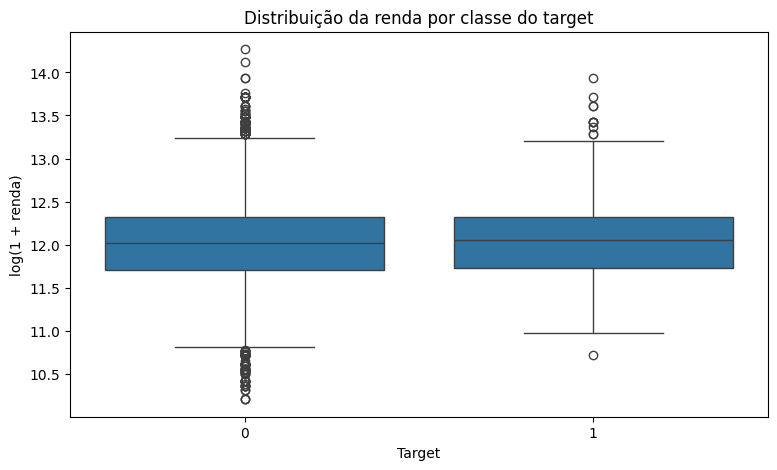

In [34]:
# ============================================================
# 27. RENDA POR CLASSE DO TARGET
# ============================================================

df["LOG_INCOME"] = np.log1p(df["AMT_INCOME_TOTAL"])

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x=TARGET,
    y="LOG_INCOME"
)

plt.title("Distribuição da renda por classe do target")
plt.xlabel("Target")
plt.ylabel("log(1 + renda)")

plt.show()

### Interpretação

As distribuições de renda são semelhantes entre as classes. A transformação logarítmica facilita a comparação visual sem alterar a variável original.

In [35]:
# Remove variável criada exclusivamente para visualização
df.drop(columns=["LOG_INCOME"], inplace=True)

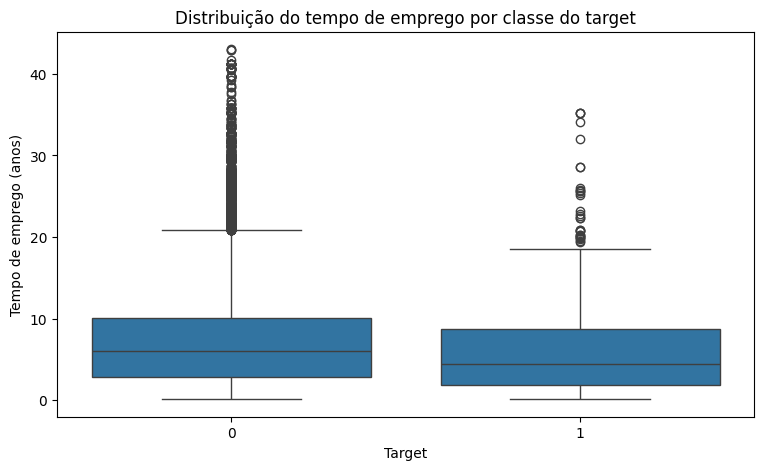

In [36]:
# ============================================================
# 28. TEMPO DE EMPREGO POR CLASSE DO TARGET
# ============================================================

df_emprego = df.loc[
    df["DAYS_EMPLOYED"] < 0
].copy()

df_emprego["EMPLOYMENT_YEARS"] = (
    -df_emprego["DAYS_EMPLOYED"] / 365.25
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_emprego,
    x=TARGET,
    y="EMPLOYMENT_YEARS"
)

plt.title("Distribuição do tempo de emprego por classe do target")
plt.xlabel("Target")
plt.ylabel("Tempo de emprego (anos)")

plt.show()

### Interpretação

O tempo de emprego apresenta sobreposição entre as classes, sem evidência visual de forte separação. O código especial `365243` foi desconsiderado nesta comparação.

In [37]:
# ============================================================
# 29. TAXA DO TARGET POR TIPO DE RENDA
# ============================================================

taxa_target_renda = (
    df.groupby("NAME_INCOME_TYPE")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_renda["percentual_target_1"] = (
    taxa_target_renda["mean"] * 100
).round(2)

taxa_target_renda

,count,sum,mean,percentual_target_1
NAME_INCOME_TYPE,,,,
Commercial associate,3992,147,0.036824,3.68
Working,8467,269,0.031770,3.18
State servant,1364,40,0.029326,2.93
Pensioner,2709,75,0.027685,2.77
Student,9,0,0.000000,0.00


### Interpretação

`Commercial associate` apresentou a maior taxa de `target = 1` (**3,68%**). As diferenças são descritivas e a categoria `Student`, com apenas nove registros, exige cautela.

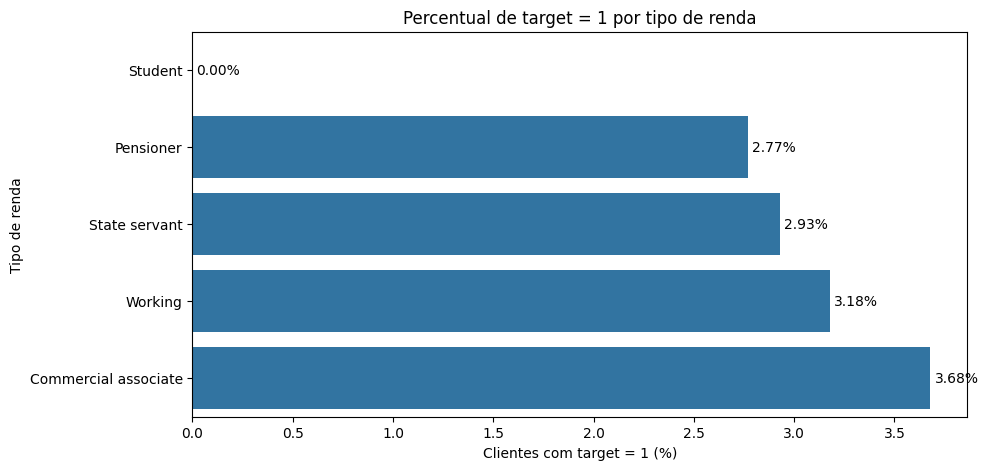

In [38]:
# ============================================================
# 30. TAXA DE TARGET = 1 POR TIPO DE RENDA
# ============================================================

plt.figure(figsize=(10, 5))

ordem = taxa_target_renda["percentual_target_1"].sort_values().index

ax = sns.barplot(
    data=taxa_target_renda.reset_index(),
    x="percentual_target_1",
    y="NAME_INCOME_TYPE",
    order=ordem
)

plt.title("Percentual de target = 1 por tipo de renda")
plt.xlabel("Clientes com target = 1 (%)")
plt.ylabel("Tipo de renda")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

### Interpretação

O gráfico mostra diferenças relativamente pequenas entre as categorias mais frequentes de renda, sem indicar associação causal.

In [39]:
# ============================================================
# 31. TAXA DO TARGET POR NÍVEL DE ESCOLARIDADE
# ============================================================

taxa_target_escolaridade = (
    df.groupby("NAME_EDUCATION_TYPE")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_escolaridade["percentual_target_1"] = (
    taxa_target_escolaridade["mean"] * 100
).round(2)

taxa_target_escolaridade

,count,sum,mean,percentual_target_1
NAME_EDUCATION_TYPE,,,,
Incomplete higher,644,36,0.055901,5.59
Secondary / secondary special,11123,360,0.032365,3.24
Lower secondary,176,5,0.028409,2.84
Higher education,4581,130,0.028378,2.84
Academic degree,17,0,0.000000,0.00


### Interpretação

`Incomplete higher` apresentou a maior taxa de `target = 1` (**5,59%**), enquanto `Academic degree` não registrou eventos, mas possui somente 17 clientes.

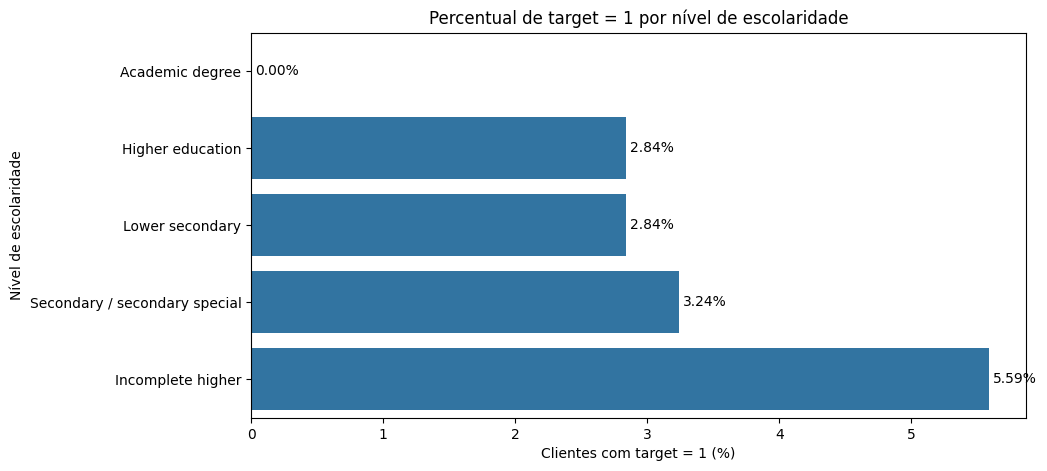

In [40]:
# ============================================================
# 32. TAXA DE TARGET = 1 POR NÍVEL DE ESCOLARIDADE
# ============================================================

plt.figure(figsize=(10, 5))

ordem = (
    taxa_target_escolaridade["percentual_target_1"]
    .sort_values()
    .index
)

ax = sns.barplot(
    data=taxa_target_escolaridade.reset_index(),
    x="percentual_target_1",
    y="NAME_EDUCATION_TYPE",
    order=ordem
)

plt.title("Percentual de target = 1 por nível de escolaridade")
plt.xlabel("Clientes com target = 1 (%)")
plt.ylabel("Nível de escolaridade")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

### Interpretação

A escolaridade apresenta diferenças descritivas entre categorias. As taxas devem ser analisadas conjuntamente com a quantidade de clientes de cada grupo.

In [41]:
# ============================================================
# 33. TAXA DO TARGET POR ESTADO CIVIL
# ============================================================

taxa_target_estado_civil = (
    df.groupby("NAME_FAMILY_STATUS")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_estado_civil["percentual_target_1"] = (
    taxa_target_estado_civil["mean"] * 100
).round(2)

taxa_target_estado_civil

,count,sum,mean,percentual_target_1
NAME_FAMILY_STATUS,,,,
Single / not married,2101,85,0.040457,4.05
Civil marriage,1244,46,0.036977,3.70
Married,11575,353,0.030497,3.05
Widow,645,19,0.029457,2.95
Separated,976,28,0.028689,2.87


### Interpretação

`Single / not married` apresentou a maior taxa de `target = 1` (**4,05%**), seguida por `Civil marriage` (**3,70%**). As diferenças não estabelecem causalidade.

In [42]:
# ============================================================
# 34. TAXA DO TARGET POR TIPO DE OCUPAÇÃO
# ============================================================

df["OCCUPATION_TYPE_EDA"] = df["OCCUPATION_TYPE"].fillna("Missing")

taxa_target_ocupacao = (
    df.groupby("OCCUPATION_TYPE_EDA")[TARGET]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

taxa_target_ocupacao["percentual_target_1"] = (
    taxa_target_ocupacao["mean"] * 100
).round(2)

taxa_target_ocupacao

,count,sum,mean,percentual_target_1
OCCUPATION_TYPE_EDA,,,,
IT staff,31,3,0.096774,9.68
Secretaries,59,4,0.067797,6.78
Low-skill Laborers,80,5,0.062500,6.25
Waiters/barmen staff,54,3,0.055556,5.56
High skill tech staff,685,32,0.046715,4.67
Managers,1421,56,0.039409,3.94
Security staff,262,10,0.038168,3.82
Core staff,1610,58,0.036025,3.60
Cooking staff,279,10,0.035842,3.58


### Interpretação

As maiores taxas foram observadas em `IT staff` (**9,68%**) e `Secretaries` (**6,78%**), categorias com poucos registros e estimativas menos estáveis.

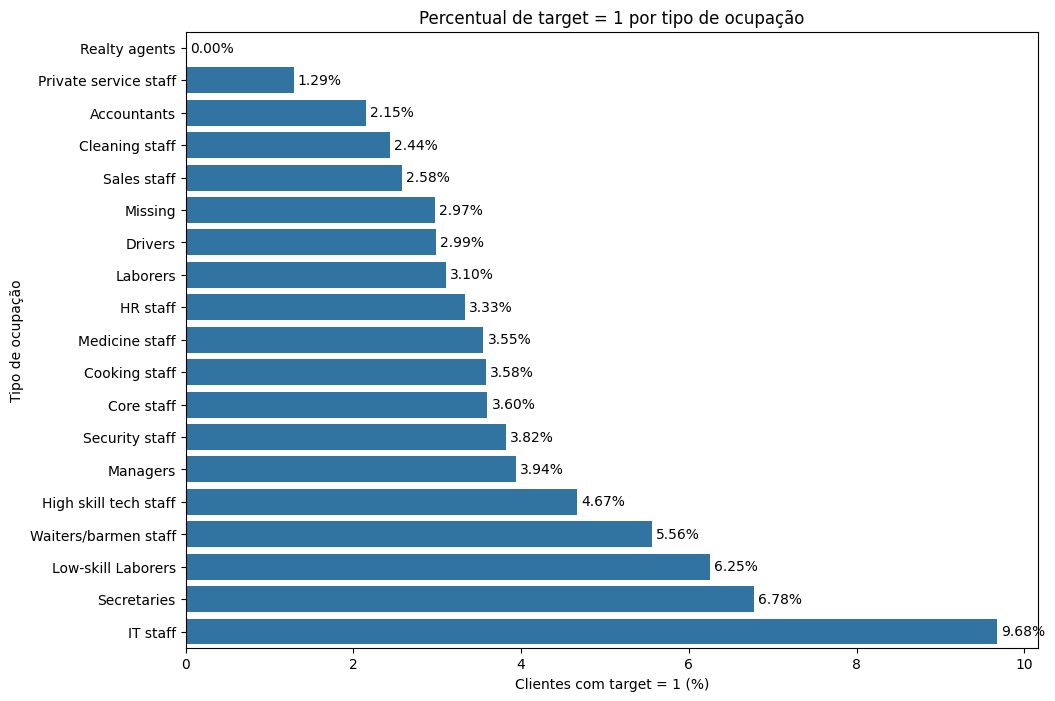

In [43]:
# ============================================================
# 35. TAXA DE TARGET = 1 POR TIPO DE OCUPAÇÃO
# ============================================================

plt.figure(figsize=(11, 8))

ordem = (
    taxa_target_ocupacao["percentual_target_1"]
    .sort_values()
    .index
)

ax = sns.barplot(
    data=taxa_target_ocupacao.reset_index(),
    x="percentual_target_1",
    y="OCCUPATION_TYPE_EDA",
    order=ordem
)

plt.title("Percentual de target = 1 por tipo de ocupação")
plt.xlabel("Clientes com target = 1 (%)")
plt.ylabel("Tipo de ocupação")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.show()

### Interpretação

O gráfico evidencia diferenças entre ocupações, mas as taxas mais elevadas ocorrem em grupos pequenos. A interpretação deve considerar o tamanho amostral.

In [44]:
# Remove variável criada exclusivamente para o EDA
df.drop(columns=["OCCUPATION_TYPE_EDA"], inplace=True)


### Interpretação consolidada — Relações com o TARGET

As distribuições de idade, renda e tempo de emprego apresentam considerável sobreposição entre as classes do `target`, sem separação visual acentuada. A análise isolada dessas características não demonstra capacidade discriminatória elevada.

Por tipo de renda, a maior taxa de `target = 1` foi observada em `Commercial associate` (**3,68%**), seguida por `Working` (**3,18%**), `State servant` (**2,93%**) e `Pensioner` (**2,77%**). A categoria `Student` não apresentou eventos, mas possui apenas nove observações.

Na escolaridade, `Incomplete higher` apresentou a maior taxa (**5,59%**), seguida por `Secondary / secondary special` (**3,24%**). As categorias `Higher education` e `Lower secondary` apresentaram taxas próximas de **2,84%**.

Quanto ao estado civil, `Single / not married` apresentou taxa de **4,05%**, seguida por `Civil marriage` (**3,70%**) e `Married` (**3,05%**).

Na ocupação, destacam-se `IT staff` (**9,68%**) e `Secretaries` (**6,78%**). Entretanto, essas categorias possuem poucos registros, tornando suas taxas menos estáveis. A categoria `Missing` apresentou taxa de aproximadamente **2,97%**.

As diferenças observadas são descritivas e devem ser interpretadas considerando o tamanho de cada grupo. Não permitem estabelecer causalidade nem determinar isoladamente o desempenho preditivo das variáveis.


## 5 — Relações entre variáveis
Nesta etapa são analisadas as relações entre as principais variáveis quantitativas da base, com o objetivo de identificar associações relevantes e possíveis redundâncias entre as variáveis explicativas.

In [45]:
# ============================================================
# 36. CORRELAÇÃO ENTRE VARIÁVEIS QUANTITATIVAS
# ============================================================

variaveis_correlacao = [
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS",
    TARGET
]

matriz_corr = df[variaveis_correlacao].corr()

matriz_corr.round(3)

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,target
CNT_CHILDREN,1.000,0.037,0.351,-0.224,0.888,0.011
AMT_INCOME_TOTAL,0.037,1.000,0.072,-0.179,0.033,0.013
DAYS_BIRTH,0.351,0.072,1.000,-0.603,0.315,0.034
DAYS_EMPLOYED,-0.224,-0.179,-0.603,1.000,-0.221,-0.018
CNT_FAM_MEMBERS,0.888,0.033,0.315,-0.221,1.000,0.005
target,0.011,0.013,0.034,-0.018,0.005,1.000


### Interpretação

Destaca-se a correlação positiva entre número de filhos e tamanho da família (**0,888**). As correlações individuais com o `target` são baixas.

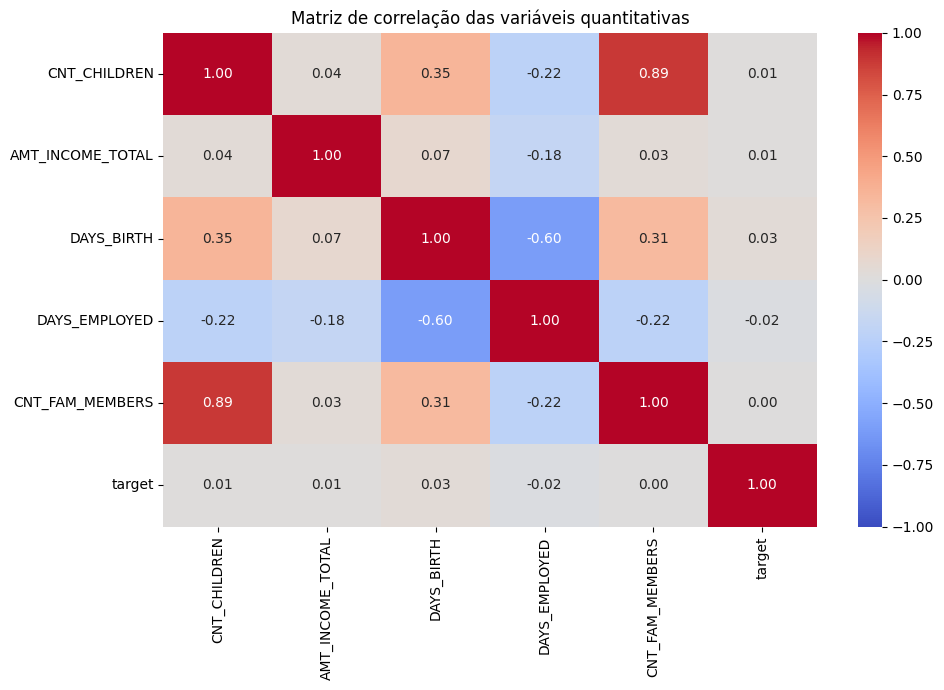

In [46]:
# ============================================================
# 37. HEATMAP DA MATRIZ DE CORRELAÇÃO
# ============================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlação das variáveis quantitativas")
plt.tight_layout()
plt.show()

### Interpretação

O heatmap confirma a forte associação entre composição familiar e número de filhos. A correlação envolvendo `DAYS_EMPLOYED` exige cautela devido à presença do código especial `365243`.


### Interpretação consolidada — Correlações

A matriz de correlação e o heatmap evidenciam forte associação positiva entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS` (**0,888**), indicando possível redundância entre essas variáveis.

Também foi observada correlação negativa entre `DAYS_BIRTH` e `DAYS_EMPLOYED` (aproximadamente **-0,60**). Essa associação deve ser interpretada com cautela, pois `DAYS_EMPLOYED` contém o código especial `365243`.

As correlações lineares individuais com o `target` são baixas. Entretanto, a correlação de Pearson não captura necessariamente relações não lineares ou interações entre variáveis.

Esses resultados serão considerados nas etapas de pré-processamento e modelagem.



## 6 — Síntese da análise exploratória

A análise exploratória foi realizada sobre uma base de **16.541 clientes e 19 variáveis**, obtida após a integração dos dados cadastrais com a variável-alvo construída a partir do histórico de crédito.

A variável `target` apresenta forte desbalanceamento, com **16.010 clientes (96,79%)** na classe 0 e **531 (3,21%)** na classe 1. Essa característica deverá orientar a escolha das estratégias de treinamento e das métricas de avaliação dos modelos.

Entre os principais pontos de atenção, destacam-se:

- **Valores ausentes:** `OCCUPATION_TYPE` apresenta 5.090 registros sem informação (30,77%).
- **Tempo de emprego:** 2.693 registros (16,28%) apresentam o código especial `365243`, que não representa um tempo de emprego interpretável.
- **Renda:** a distribuição apresenta assimetria à direita e valores extremos.
- **Perfis cadastrais semelhantes:** foram identificados 3.805 perfis compartilhados por múltiplos IDs, dos quais 274 apresentam divergência na classificação do `target`.
- **Correlação:** `CNT_CHILDREN` e `CNT_FAM_MEMBERS` apresentam associação positiva elevada (aproximadamente 0,89), indicando possível redundância de informações.

As análises bivariadas mostram diferenças descritivas entre grupos, mas não permitem estabelecer relações causais nem demonstram, isoladamente, elevada capacidade de discriminação da variável-alvo.

Os resultados indicam a necessidade de atenção ao tratamento dos valores ausentes, à codificação de variáveis categóricas, à prevenção de vazamento de informações entre treino e teste e ao desbalanceamento das classes.

Essas questões serão abordadas nas etapas de pré-processamento e modelagem.
